# 🏠 House Prices — Seaborn Visualizations
Fixed notebook: cleaned estimator warnings, added hue fix, improved dashboard.

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('train.csv')
print('Shape:', df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
df.columns.tolist()

['Id',
 'MSSubClass',
 'MSZoning',
 'LotFrontage',
 'LotArea',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinSF1',
 'BsmtFinType2',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'KitchenQual',
 'TotRmsAbvGrd',
 'Functional',
 'Fireplaces',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageCars',
 'GarageArea',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'WoodDeckSF',
 'OpenPorchSF'

## 1. Average Sale Price by Neighborhood

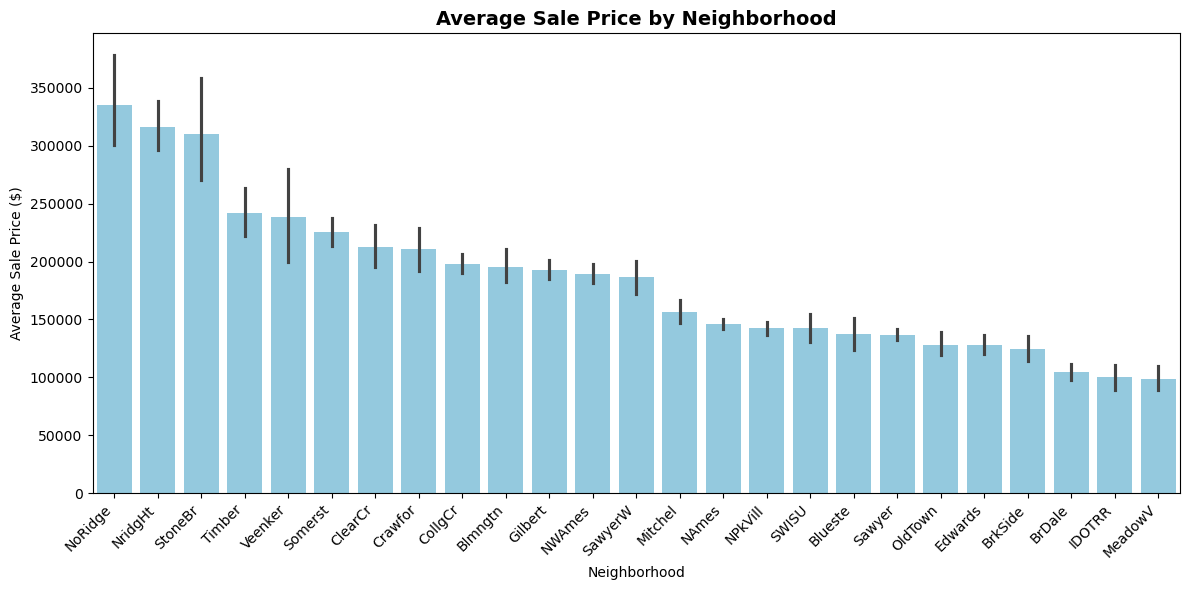

In [17]:
plt.figure(figsize=(12, 6))
# FIX: estimator='mean' → estimator=None not needed; just pass string directly (seaborn 0.12+)
neighborhood_order = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='Neighborhood', y='SalePrice', estimator='mean',
            order=neighborhood_order, color='skyblue')
plt.title('Average Sale Price by Neighborhood', fontsize=14, fontweight='bold')
plt.xlabel('Neighborhood')
plt.ylabel('Average Sale Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Sale Price vs Above Ground Living Area

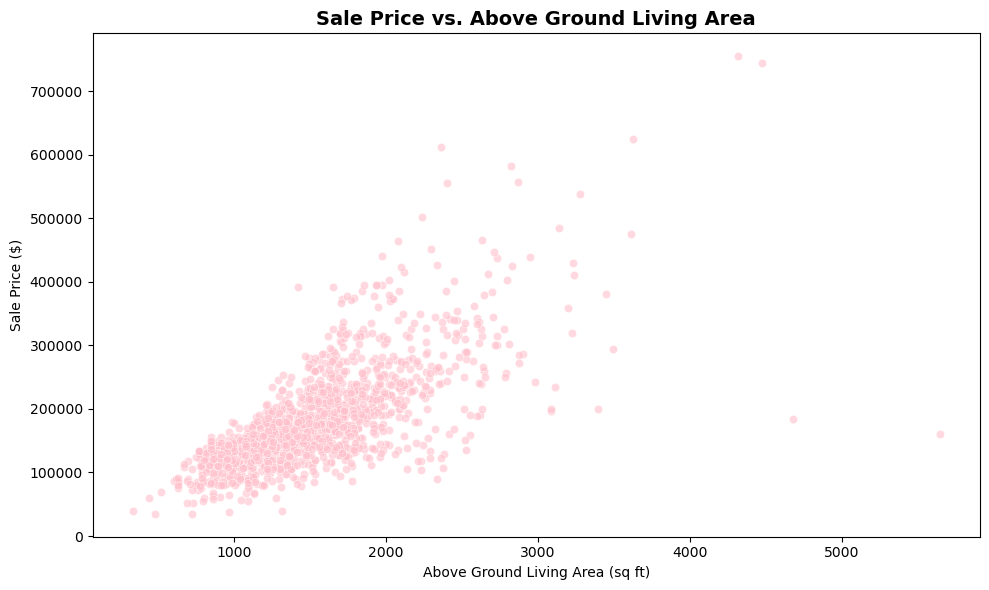

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', color='pink', alpha=0.6)
plt.title('Sale Price vs. Above Ground Living Area', fontsize=14, fontweight='bold')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

## 3. Distribution of Sale Prices

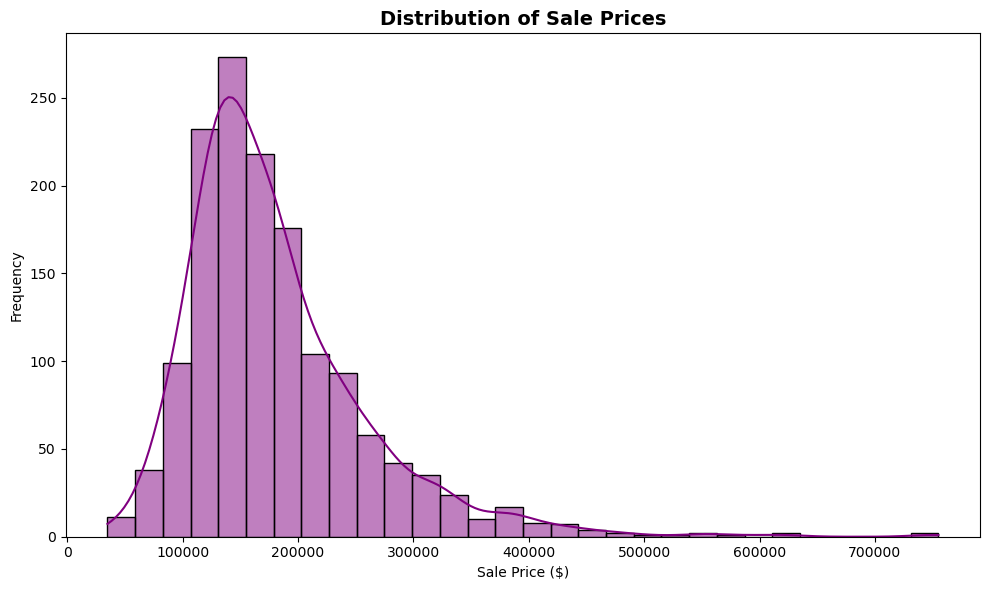

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='SalePrice', bins=30, kde=True, color='purple')
plt.title('Distribution of Sale Prices', fontsize=14, fontweight='bold')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## 4. Sale Price by House Style

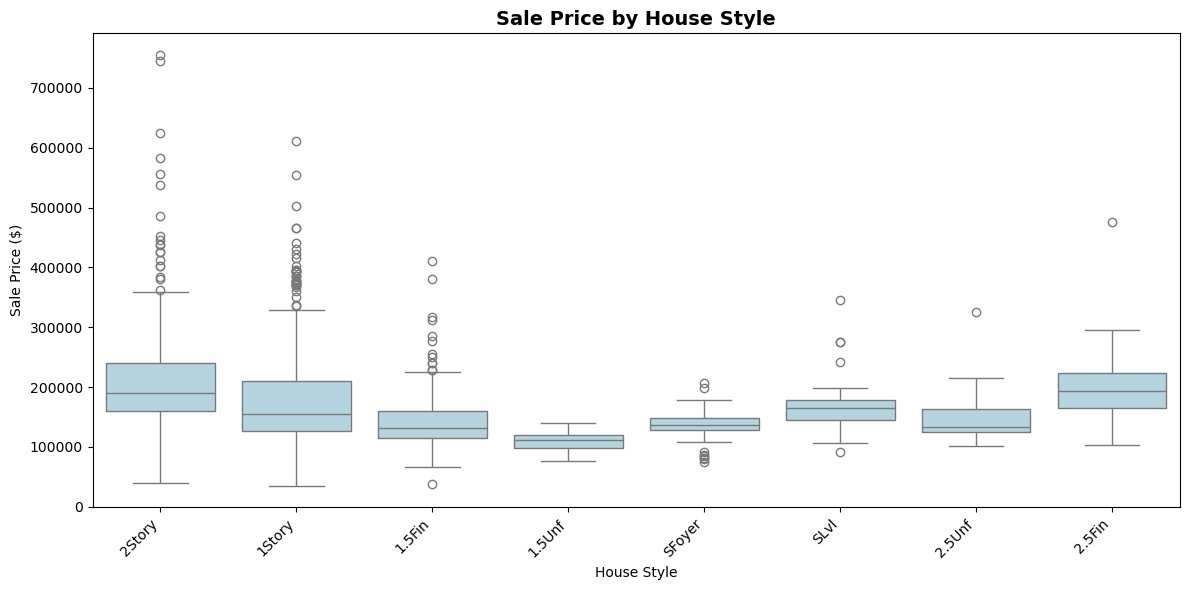

In [26]:
plt.figure(figsize=(12, 6))
# FIX: palette added for clarity since no hue used — use color instead
sns.boxplot(data=df, x='HouseStyle', y='SalePrice', color='lightblue')
plt.title('Sale Price by House Style', fontsize=14, fontweight='bold')
plt.xlabel('House Style')
plt.ylabel('Sale Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. 2×2 Dashboard

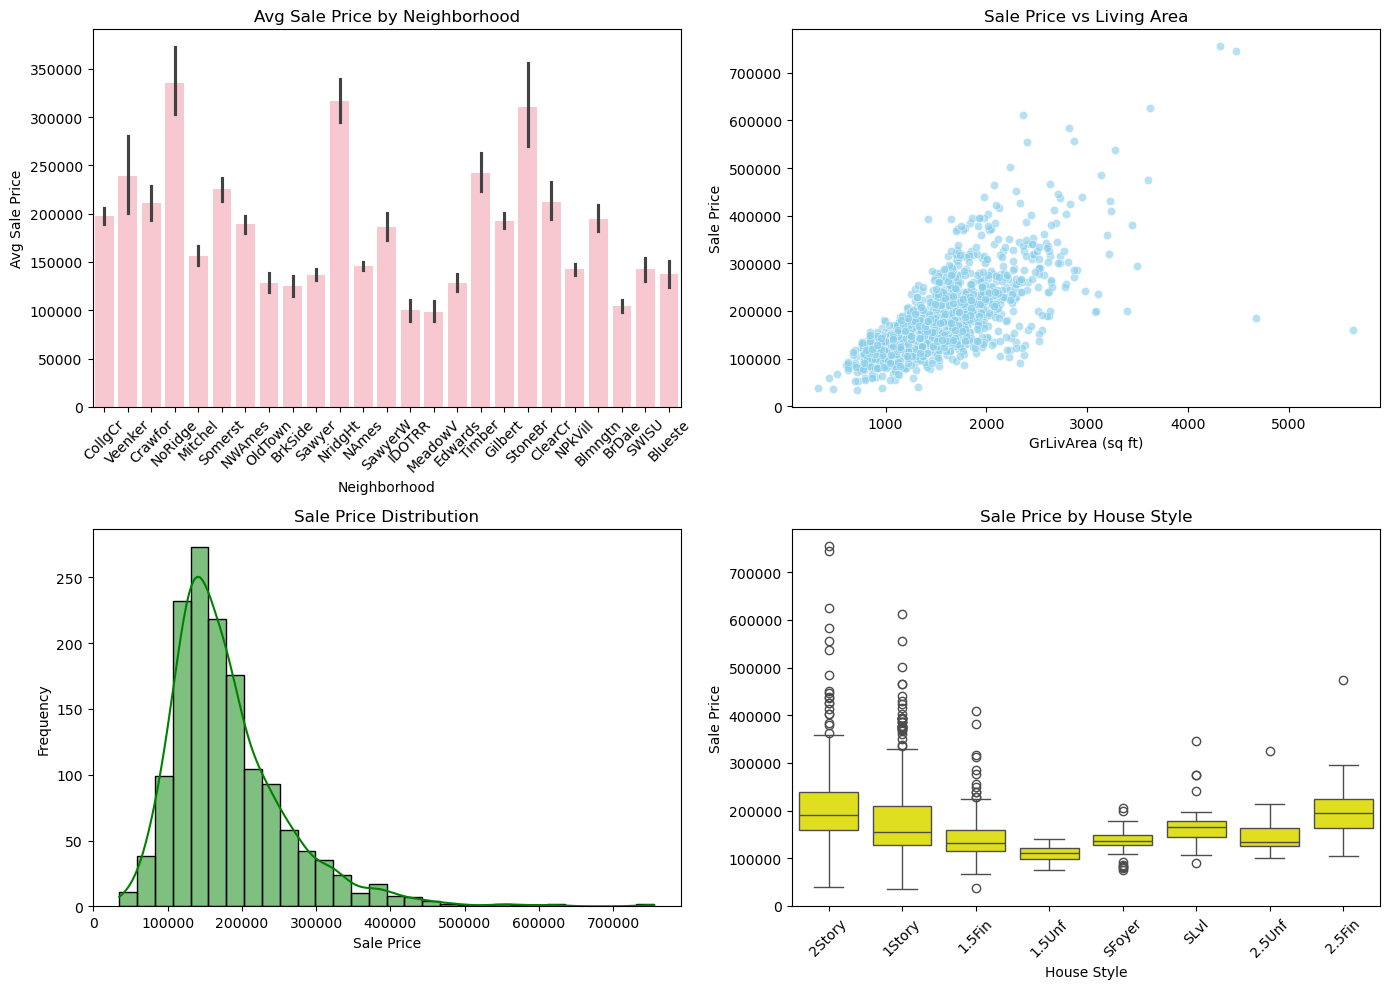

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Bar plot
sns.barplot(data=df, x='Neighborhood', y='SalePrice', estimator='mean',
            ax=axs[0,0], color='pink')
axs[0,0].set_title('Avg Sale Price by Neighborhood')
axs[0,0].set_xlabel('Neighborhood'); axs[0,0].set_ylabel('Avg Sale Price')
axs[0,0].tick_params(axis='x', rotation=45)

# Scatter plot
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', ax=axs[0,1], color='skyblue', alpha=0.6)
axs[0,1].set_title('Sale Price vs Living Area')
axs[0,1].set_xlabel('GrLivArea (sq ft)'); axs[0,1].set_ylabel('Sale Price')

# Histogram
sns.histplot(data=df, x='SalePrice', bins=30, kde=True, ax=axs[1,0], color='green')
axs[1,0].set_title('Sale Price Distribution')
axs[1,0].set_xlabel('Sale Price'); axs[1,0].set_ylabel('Frequency')

# Box plot — FIX: removed palette warning by using color only
sns.boxplot(data=df, x='HouseStyle', y='SalePrice', ax=axs[1,1], color='yellow')
axs[1,1].set_title('Sale Price by House Style')
axs[1,1].set_xlabel('House Style'); axs[1,1].set_ylabel('Sale Price')
axs[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Full 2×3 Dashboard

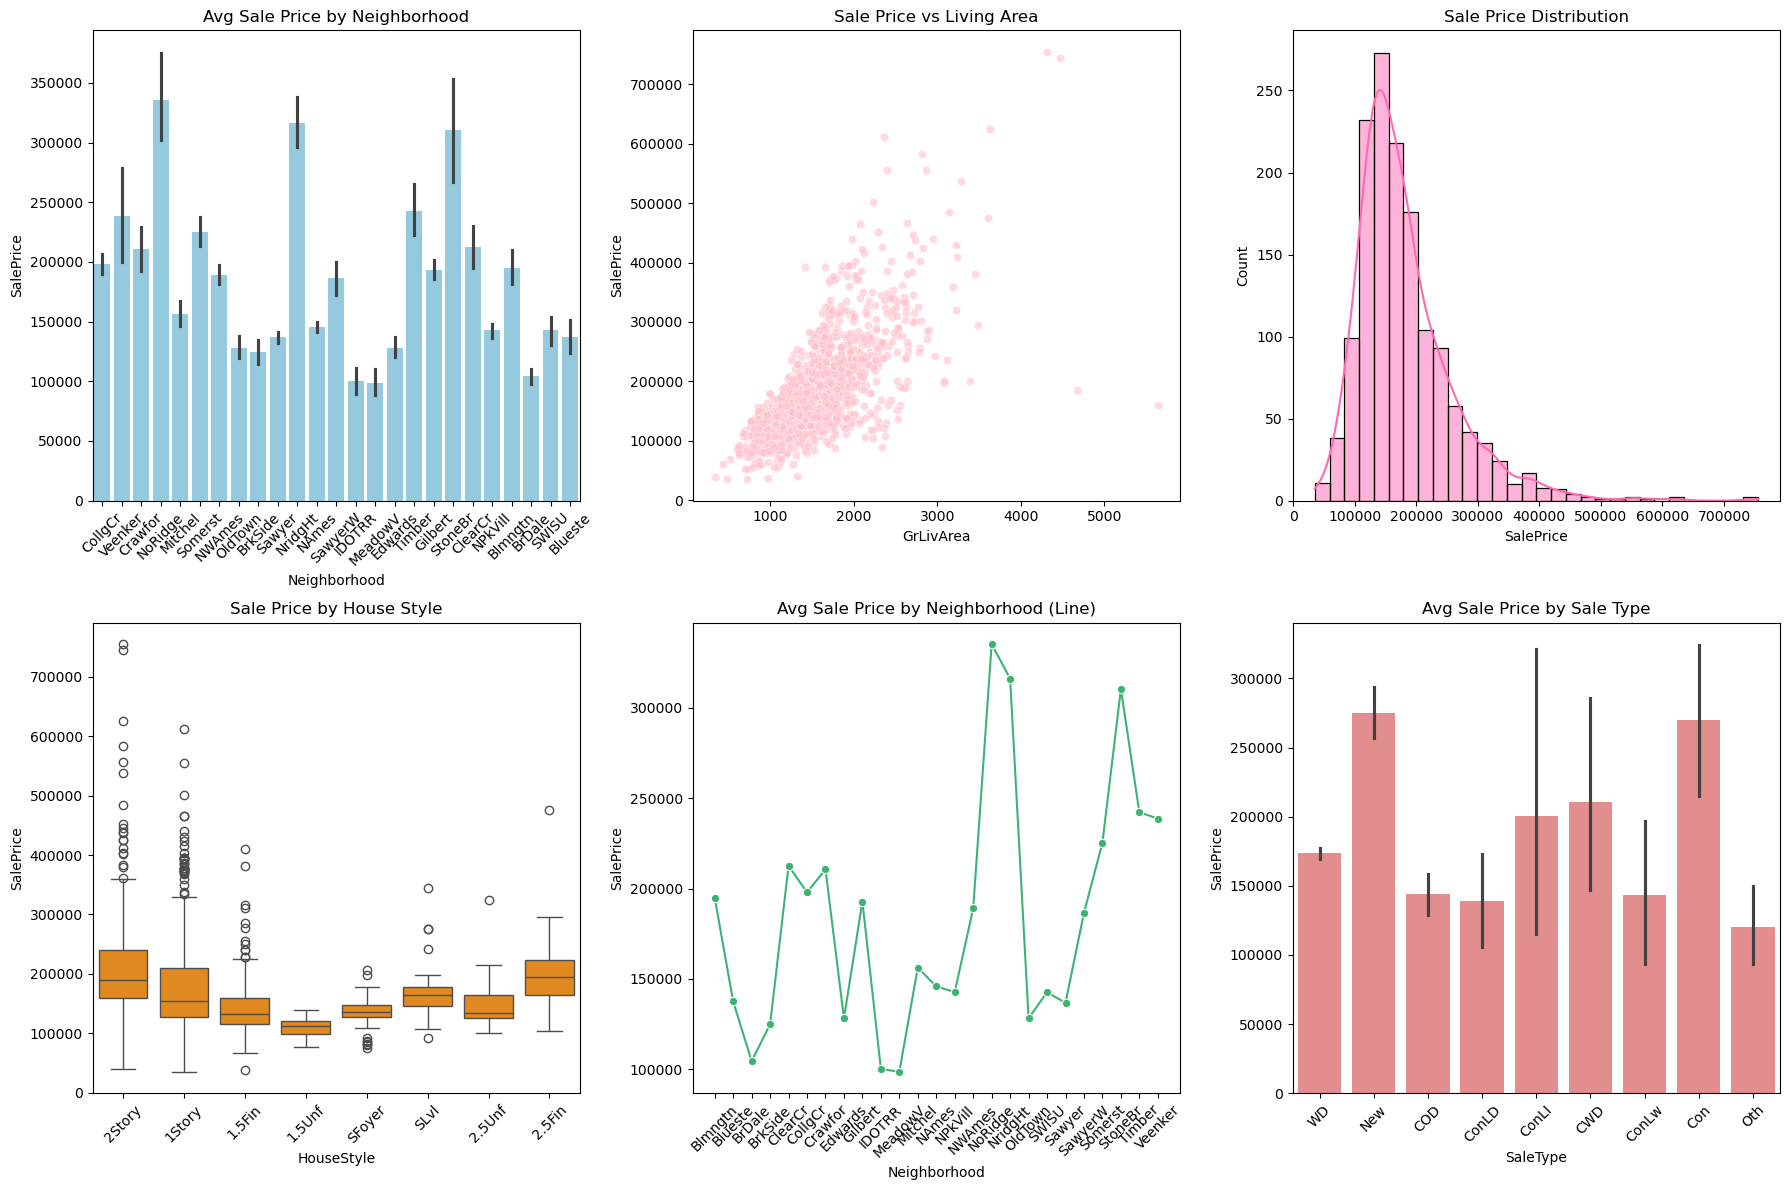

In [32]:
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

# 1. Bar Plot
sns.barplot(data=df, x='Neighborhood', y='SalePrice', estimator='mean',
            ax=axs[0,0], color='skyblue')
axs[0,0].set_title('Avg Sale Price by Neighborhood')
axs[0,0].tick_params(axis='x', rotation=45)

# 2. Scatter Plot
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', ax=axs[0,1], color='pink', alpha=0.6)
axs[0,1].set_title('Sale Price vs Living Area')

# 3. Histogram
sns.histplot(data=df, x='SalePrice', bins=30, kde=True, ax=axs[0,2], color='hotpink')
axs[0,2].set_title('Sale Price Distribution')

# 4. Box Plot
sns.boxplot(data=df, x='HouseStyle', y='SalePrice', ax=axs[1,0], color='darkorange')
axs[1,0].set_title('Sale Price by House Style')
axs[1,0].tick_params(axis='x', rotation=45)

# 5. Line Plot
avg_sale_price = df.groupby('Neighborhood')['SalePrice'].mean().reset_index()
sns.lineplot(data=avg_sale_price, x='Neighborhood', y='SalePrice',
             ax=axs[1,1], marker='o', color='mediumseagreen')
axs[1,1].set_title('Avg Sale Price by Neighborhood (Line)')
axs[1,1].tick_params(axis='x', rotation=45)

# 6. Bar Plot by Sale Type
sns.barplot(data=df, x='SaleType', y='SalePrice', estimator='mean',
            ax=axs[1,2], color='lightcoral')
axs[1,2].set_title('Avg Sale Price by Sale Type')
axs[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Bonus — Correlation Heatmap

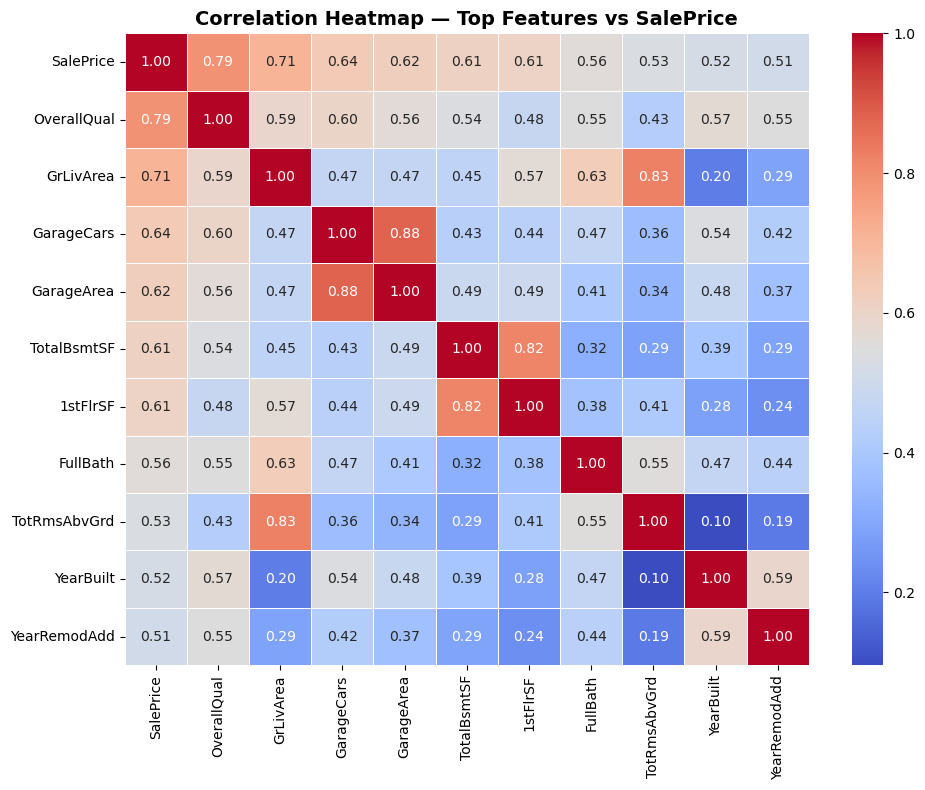

In [35]:
# Top 10 features most correlated with SalePrice
numeric_df = df.select_dtypes(include='number')
top_corr = numeric_df.corr()['SalePrice'].abs().sort_values(ascending=False).head(11).index

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[top_corr].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Top Features vs SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()